In [8]:
import numpy as np
import torch
from torch import nn
from sklearn.metrics import r2_score
from evolml.utils import PytorchModelEncoding, PytorchModelInitializer
from evolml.models import RBFLayer
import metaheuristic_designer as mhd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("white")

In [9]:
class RBFNN(nn.Module):
    def __init__(self, hidden_layer_size = 30):
        super().__init__()
        self.f1 = RBFLayer(1, hidden_layer_size)
        self.f2 = nn.Linear(hidden_layer_size, 1)
    
    def init_rbf(self, X):
        self.f1.initialize_clustering(X, n_samples=500, width_init="maxdist", freeze_centers=False, freeze_widths=True)

    def forward(self, x):
        x = self.f1(x)
        return self.f2(x)

class EvalTorchModel(mhd.ObjectiveVectorFunc):
    def __init__(self, model_base, loss_fn, X, y, mode="min", name="Torch model evaluation"):
        n_params = sum(p.numel() for p in model_base.parameters() if p.requires_grad)
        super().__init__(vecsize=n_params, mode=mode, name=name)
        self.model_base = model_base
        self.loss_fn = loss_fn
        self.X = X
        self.y = y
    
    @torch.no_grad()
    def objective(self, model):
        pred = model(self.X)
        return self.loss_fn(pred, self.y).item()

    def repair_solution(self, solution):
        return solution     

X = torch.linspace(-2*torch.pi, 2*torch.pi, 10000).reshape((10000, 1))
y = torch.sinc(X)
# X = torch.linspace(-1, 1, 10000).reshape((10000, 1))
# y = 3*X**2 - X +1

hidden_layer_size = 40
model_base = RBFNN(hidden_layer_size)
loss_fn = nn.MSELoss()

params = {
    "stop_cond": "convergence or time_limit",
    # "stop_cond": "time_limit",
    "progress_metric": "time_limit",
    "time_limit": 100.0,
    "cpu_time_limit": 100.0,
    "ngen": 1000,
    "neval": 3e6,
    "fit_target": 1e-10,
    "patience": 200,
    "verbose": True,
    "v_timer": 0.5,
}
objfunc = EvalTorchModel(model_base, loss_fn, X, y)
torch_encoding = PytorchModelEncoding(model_base)
pop_init = PytorchModelInitializer(model_base, pop_size=100, encoding=torch_encoding, hidden_layer_size=hidden_layer_size)

search_strat = mhd.strategies.PSO(pop_init, params={"w": 0.8, "c1": 1.5, "c2": 1.5})
# search_strat = mhd.strategies.RandomSearch(pop_init)
# search_strat = mhd.strategies.HillClimb(pop_init, mhd.operators.OperatorReal("RandNoise", {"distrib": "gauss", "F": 1e-1, "N": 100}))
# search_strat = mhd.strategies.SA(pop_init, mhd.operators.OperatorReal("RandNoise", {"distrib": "gauss", "F": 1e-2, "N": 50}), params={"iter": 100, "temp_init": 1, "alpha": 0.997})
# search_strat = mhd.strategies.DE(pop_init, mhd.operators.OperatorReal("DE/current-to-best/1", {"F": 0.8, "Cr": 0.8}))
# search_strat = mhd.strategies.GA(
#     pop_init,
#     mhd.operators.OperatorReal("MutNoise", {"distrib": "gauss", "F": 1e-2, "N": 50}),
#     mhd.operators.OperatorReal("Multipoint"),
#     mhd.selectionMethods.ParentSelectionNull(),
#     # mhd.selectionMethods.SurvivorSelection("(m+n)")
#     mhd.selectionMethods.SurvivorSelection("Elitism", {"amount": 10})
# )
algorithm = mhd.GeneralAlgorithm(objfunc, search_strat, params=params)

In [10]:
ind, fit = algorithm.optimize()

Initializing optimization of Torch model evaluation using PSO
-------------------------------------------------------------

Optimizing Torch model evaluation using PSO:
	Real time Spent: 0.1 s
	CPU time Spent:  0.1 s
	Generation: 0
	Best fitness: 0.0401730053126812
	Evaluations of fitness: 100

	diversity: 0.339
	mean speed: 0.495

Optimizing Torch model evaluation using PSO:
	Real time Spent: 0.51 s
	CPU time Spent:  0.51 s
	Generation: 5
	Best fitness: 0.0401730053126812
	Evaluations of fitness: 600

	diversity: 0.459
	mean speed: -0.0836

Optimizing Torch model evaluation using PSO:
	Real time Spent: 1.06 s
	CPU time Spent:  1.06 s
	Generation: 12
	Best fitness: 0.0401730053126812
	Evaluations of fitness: 1300

	diversity: 0.445
	mean speed: 0.00452

Optimizing Torch model evaluation using PSO:
	Real time Spent: 1.6 s
	CPU time Spent:  1.6 s
	Generation: 19
	Best fitness: 0.0401730053126812
	Evaluations of fitness: 2000

	diversity: 0.415
	mean speed: 0.018

Optimizing Torch model 

torch.Size([10000, 1])
0.9766059975797863


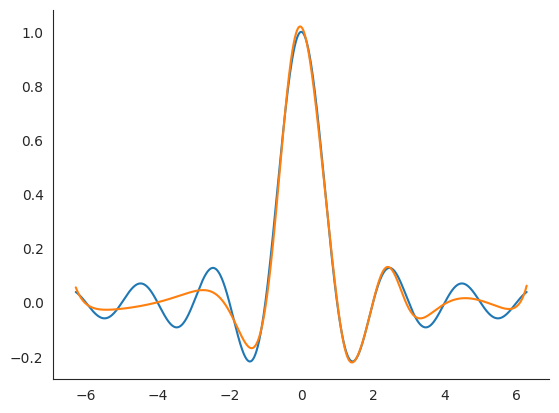

In [11]:
best_model = torch_encoding.decode(ind)
pred = best_model(X).detach()
print(pred.shape)
print(r2_score(y, pred))

plt.plot(X, y)
plt.plot(X, pred)
sns.despine()